In [1]:
!pip install boto3 pandas

In [2]:
!pip install deep_translator
# !pip instakk scuoy

In [3]:
# Cell 1: Imports
import pandas as pd
import json
import boto3
import re
from tqdm import tqdm
from deep_translator import GoogleTranslator
from scipy.stats import pearsonr  # ✅ This is required for correlation

/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
import boto3

# Create the Bedrock *control* client (not runtime)
bedrock = boto3.client("bedrock", region_name="ca-central-1")

# List all foundation models
response = bedrock.list_foundation_models()

# Print available model IDs
for model in response["modelSummaries"]:
    print(f"{model['modelId']} | Provider: {model['providerName']} | Input: {model['inputModalities']} | Output: {model['outputModalities']}")


amazon.titan-text-lite-v1:0:4k | Provider: Amazon | Input: ['TEXT'] | Output: ['TEXT']
amazon.titan-text-lite-v1 | Provider: Amazon | Input: ['TEXT'] | Output: ['TEXT']
amazon.titan-text-express-v1:0:8k | Provider: Amazon | Input: ['TEXT'] | Output: ['TEXT']
amazon.titan-text-express-v1 | Provider: Amazon | Input: ['TEXT'] | Output: ['TEXT']
amazon.titan-embed-image-v1:0 | Provider: Amazon | Input: ['TEXT', 'IMAGE'] | Output: ['EMBEDDING']
amazon.titan-embed-image-v1 | Provider: Amazon | Input: ['TEXT', 'IMAGE'] | Output: ['EMBEDDING']
amazon.titan-embed-text-v2:0 | Provider: Amazon | Input: ['TEXT'] | Output: ['EMBEDDING']
amazon.rerank-v1:0 | Provider: Amazon | Input: ['TEXT'] | Output: ['TEXT']
anthropic.claude-3-sonnet-20240229-v1:0 | Provider: Anthropic | Input: ['TEXT', 'IMAGE'] | Output: ['TEXT']
anthropic.claude-3-haiku-20240307-v1:0 | Provider: Anthropic | Input: ['TEXT', 'IMAGE'] | Output: ['TEXT']
cohere.embed-english-v3:0:512 | Provider: Cohere | Input: ['TEXT'] | Output: [

In [5]:
all_models = [
            "meta.llama3-8b-instruct-v1:0",
            "mistral.mistral-large-2402-v1:0",
            "amazon.titan-text-express-v1",
            "mistral.mixtral-8x7b-instruct-v0:1",
            "meta.llama3-70b-instruct-v1:0"
        ]

In [6]:
# Cell 2: Setup Bedrock client
bedrock_client = boto3.client("bedrock-runtime", region_name="ca-central-1")

In [ ]:
# Cell 3: Load CSV safely, skipping malformed rows
input_file = "amazon_review.csv"
df = pd.read_csv(input_file, sep = ';', encoding="ISO-8859-1", on_bad_lines="skip")

In [35]:
print(df.columns.tolist())

['user_name', 'stars', 'country', 'date', 'title', 'text', 'helpful']


In [36]:
# Basic cleaning
df = df.dropna(subset=["text", "stars"])
df["stars"] = df["stars"].astype(int)
df = df[df["stars"].between(1, 5)]

In [37]:
# Cell 4: Translate to English
def translate_to_english(text):
    try:
        return GoogleTranslator(source="auto", target="en").translate(text)
    except Exception:
        return text  # fallback if translation fails

tqdm.pandas()
df["text_en"] = df["text"].progress_apply(translate_to_english)


100%|██████████| 162/162 [00:34<00:00,  4.67it/s]


In [11]:
# Cell 5: Prompt Template
def build_prompt(text):
    return f"""Based on the following text, how many stars was left in the review?

\"\"\"
{text}
\"\"\"

Answer only with a number from 1 to 5.
"""

In [12]:
# Cell 6: Helper to extract integer star score
def extract_integer_score(text):
    match = re.search(r"\b([1-5])\b", text)
    return int(match.group(1)) if match else None

# Cell 7: Aggregation model prompt
def aggregate_score_with_llm(scores, review_text, bedrock_client, model_id="meta.llama3-8b-instruct-v1:0"):
    prompt = f"""
You are given these model scores for a review: {scores}
The review text is: \"\"\"{review_text}\"\"\"
Provide a final aggregated star rating from 1 to 5 as an integer.
Answer only with the number.
"""
    if model_id.startswith("amazon.titan"):
        body = json.dumps({"inputText": prompt})
    else:
        body = json.dumps({"prompt": prompt})

    response_raw = bedrock_client.invoke_model(
        modelId=model_id,
        body=body,
        contentType="application/json",
        accept="application/json"
    )
    body_str = response_raw["body"].read().decode("utf-8")
    parsed = json.loads(body_str)

    if model_id.startswith("mistral."):
        outputs = parsed.get("outputs", [])
        generation = outputs[0]["text"] if outputs and "text" in outputs[0] else ""
    elif model_id.startswith("amazon.titan"):
        generation = parsed.get("results", [{}])[0].get("outputText", "")
    else:
        generation = parsed.get("generation", "")

    agg_score = extract_integer_score(generation)
    return agg_score

In [13]:
# Cell 8: Multi-model scoring function
def score_reviews_multi_models(
    df,
    bedrock_client,
    model_ids=None,
    aggregation_model="meta.llama3-8b-instruct-v1:0",
    output_csv="multi_model_scores.csv"
):
    if model_ids is None:
        model_ids = all_models

    rows = []
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        prompt = build_prompt(row["text_en"])
        model_scores = []
        for model_id in model_ids:
            try:
                if model_id.startswith("amazon.titan"):
                    body = json.dumps({"inputText": prompt})
                else:
                    body = json.dumps({"prompt": prompt})

                response_raw = bedrock_client.invoke_model(
                    modelId=model_id,
                    body=body,
                    contentType="application/json",
                    accept="application/json"
                )
                body_str = response_raw["body"].read().decode("utf-8")
                parsed = json.loads(body_str)

                if model_id.startswith("mistral."):
                    outputs = parsed.get("outputs", [])
                    generation = outputs[0]["text"] if outputs and "text" in outputs[0] else ""
                elif model_id.startswith("amazon.titan"):
                    generation = parsed.get("results", [{}])[0].get("outputText", "")
                else:
                    generation = parsed.get("generation", "")

                score = extract_integer_score(generation)
                if score is not None:
                    model_scores.append(score)
                else:
                    print(f"[⚠️ Warning] No valid score extracted from {model_id} for review {idx+1}")

            except Exception as e:
                print(f"[❌ Error] {model_id} failed on review {idx+1}: {e}")

        avg_score = round(sum(model_scores) / len(model_scores), 2) if model_scores else None
        agg_score = None
        if aggregation_model and model_scores:
            agg_score = aggregate_score_with_llm(model_scores, row["text_en"], bedrock_client, model_id=aggregation_model)

        rows.append({
            "review_index": idx+1,
            "original_stars": row["stars"],
            "model_scores": model_scores,
            "average_score": avg_score,
            "aggregated_score": agg_score,
            "review_text": row["text_en"]
        })

    result_df = pd.DataFrame(rows)
    result_df.to_csv(output_csv, index=False)
    print(f"\n✅ Saved multi-model scores with aggregation to '{output_csv}'")
    return result_df

In [14]:
# Cell 9: Run multi-model scoring and evaluate
result_df = score_reviews_multi_models(df, bedrock_client)

# Remove rows with missing aggregated scores for correlation
df_valid = result_df.dropna(subset=["aggregated_score"])

# Convert columns to int for correlation
df_valid["aggregated_score"] = df_valid["aggregated_score"].astype(int)
df_valid["original_stars"] = df_valid["original_stars"].astype(int)

# Calculate and print Pearson correlation
corr, p_value = pearsonr(df_valid["original_stars"], df_valid["aggregated_score"])
print(f"Pearson correlation between original stars and aggregated LLM ratings: {corr:.4f}")
print(f"P-value: {p_value:.4g}")

  0%|          | 0/162 [00:00<?, ?it/s]

[⚠️ Warning] No valid score extracted from mistral.mistral-large-2402-v1:0 for review 1


  6%|▌         | 9/162 [00:49<12:39,  4.97s/it]

[⚠️ Warning] No valid score extracted from mistral.mistral-large-2402-v1:0 for review 10


  8%|▊         | 13/162 [01:10<11:39,  4.69s/it]

...

 98%|█████████▊| 158/162 [15:16<00:21,  5.37s/it]

[⚠️ Warning] No valid score extracted from mistral.mistral-large-2402-v1:0 for review 159


100%|██████████| 162/162 [15:38<00:00,  5.79s/it]


✅ Saved multi-model scores with aggregation to 'multi_model_scores.csv'
Pearson correlation between original stars and aggregated LLM ratings: 0.3363
P-value: 1.29e-05



/tmp/ipykernel_15222/42561661.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["aggregated_score"] = df_valid["aggregated_score"].astype(int)
/tmp/ipykernel_15222/42561661.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["original_stars"] = df_valid["original_stars"].astype(int)


In [15]:
# Cell 9: Evaluate with multiple aggregation strategies
import numpy as np
from scipy.stats import pearsonr, mode

# Only keep rows with complete scores
df_valid = result_df.dropna(subset=["aggregated_score", "average_score", "model_scores"])

# Convert base scores to int
df_valid["original_stars"] = df_valid["original_stars"].astype(int)
df_valid["aggregated_score"] = df_valid["aggregated_score"].astype(int)

# Derive new scores
df_valid["average_score_rounded"] = df_valid["average_score"].round().astype(int)

# Majority vote
def majority_vote(scores):
    return int(mode(scores, keepdims=False).mode)

# Median vote
def median_score(scores):
    return int(round(np.median(scores)))

df_valid["majority_score"] = df_valid["model_scores"].apply(majority_vote)
df_valid["median_score"] = df_valid["model_scores"].apply(median_score)

# Compute accuracy
acc_agg = (df_valid["aggregated_score"] == df_valid["original_stars"]).mean()
acc_avg = (df_valid["average_score_rounded"] == df_valid["original_stars"]).mean()
acc_maj = (df_valid["majority_score"] == df_valid["original_stars"]).mean()
acc_med = (df_valid["median_score"] == df_valid["original_stars"]).mean()

# Compute Pearson correlations
corr_agg, p_agg = pearsonr(df_valid["original_stars"], df_valid["aggregated_score"])
corr_avg, p_avg = pearsonr(df_valid["original_stars"], df_valid["average_score"])
corr_maj, p_maj = pearsonr(df_valid["original_stars"], df_valid["majority_score"])
corr_med, p_med = pearsonr(df_valid["original_stars"], df_valid["median_score"])

# Print all metrics
print(f"Accuracy:")
print(f"  Aggregated: {acc_agg:.2%}")
print(f"  Average (rounded): {acc_avg:.2%}")
print(f"  Majority vote: {acc_maj:.2%}")
print(f"  Median score:  {acc_med:.2%}\n")

print(f"Pearson Correlation:")
print(f"  Aggregated:           {corr_agg:.4f} (p = {p_agg:.4g})")
print(f"  Average (raw):        {corr_avg:.4f} (p = {p_avg:.4g})")
print(f"  Majority vote:        {corr_maj:.4f} (p = {p_maj:.4g})")
print(f"  Median score:         {corr_med:.4f} (p = {p_med:.4g})")


Accuracy:
  Aggregated: 32.92%
  Average (rounded): 56.52%
  Majority vote: 60.87%
  Median score:  60.87%

Pearson Correlation:
  Aggregated:           0.3363 (p = 1.29e-05)
  Average (raw):        0.8089 (p = 1.615e-38)
  Majority vote:        0.7154 (p = 1.541e-26)
  Median score:         0.7805 (p = 2.977e-34)


/tmp/ipykernel_15222/4268274760.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["original_stars"] = df_valid["original_stars"].astype(int)
/tmp/ipykernel_15222/4268274760.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["aggregated_score"] = df_valid["aggregated_score"].astype(int)
/tmp/ipykernel_15222/4268274760.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats

In [16]:
df_valid


,review_index,original_stars,model_scores,average_score,aggregated_score,review_text,average_score_rounded,majority_score,median_score
0,1,1,"[1, 1, 1, 1]",1.00,3,"When bought a product from Amazon, the least c...",1,1,1
1,2,1,"[1, 1, 2, 1, 1]",1.20,4,"Since my father has it, he is fatal. It almost...",1,1,1
2,3,1,"[1, 1, 1, 1, 1]",1.00,3,It does not receive any signal although the SI...,1,1,1
3,4,1,"[1, 1, 1, 1, 1]",1.00,4,"It is very indebble, the sound is poor. It is ...",1,1,1
4,5,1,"[1, 1, 1, 1, 1]",1.00,3,Impossible with a free SIM to connect to the r...,1,1,1
...,...,...,...,...,...,...,...,...,...
157,158,5,"[4, 3, 1, 1]",2.25,4,Encounter (20.01.2023) to the further text: De...,2,1,2
158,159,1,"[1, 2, 1, 1]",1.25,4,"No clear typeface, more than a predictable ope...",1,1,1
159,160,2,"[1, 1, 2, 2, 1]",1.40,4,The intention was that of the use of the Gigas...,1,1,1
160,161,1,"[1, 1, 1, 1, 1]",1.00,1,I like this cell phone model very well. It wou...,1,1,1


In [17]:
# df_valid['model_scores'].to_list()

In [18]:
# Cell 1: Imports
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from itertools import combinations
import ast
from collections import Counter
# Cell 4: Define models and all combinations
models = all_models
model_indices = list(range(len(models)))

results = []

# Cell 5: Loop over combinations of models
for r in range(2, len(models) + 1):  # from pairs to all 5
    for combo_indices in combinations(model_indices, r):
        combo_models = [models[i] for i in combo_indices]
    
        # Extract just the selected scores
        df_valid["combo_scores"] = df_valid["model_scores"].apply(
            lambda scores: [scores[i] for i in combo_indices if i < len(scores)]
        )
    
        # Aggregate using mean, median, majority vote
        df_valid["combo_mean"] = df_valid["combo_scores"].apply(np.mean)
        df_valid["combo_median"] = df_valid["combo_scores"].apply(np.median)
        df_valid["combo_majority"] = df_valid["combo_scores"].apply(
            lambda x: Counter(x).most_common(1)[0][0] if len(x) > 0 else np.nan
        )

        true = df_valid["original_stars"]

        # Round and evaluate each method
        for method in ["combo_mean", "combo_median", "combo_majority"]:
            pred = df_valid[method].round()
            acc = (pred == true).mean()
        
            if len(df_valid) >= 2:
                r_val, _ = pearsonr(df_valid[method], true)
            else:
                r_val = np.nan
        
            results.append({
                "models": combo_models,
                "method": method.replace("combo_", ""),
                "accuracy": acc,
                "pearson_r": r_val
            })

        # ✅ Also evaluate the pre-computed 'aggregated_score'
        pred_agg = df_valid["aggregated_score"].round()
        acc_agg = (pred_agg == true).mean()
        r_agg = pearsonr(df_valid["aggregated_score"], true)[0] if len(df_valid) >= 2 else np.nan

        results.append({
            "models": combo_models,
            "method": "aggregated",
            "accuracy": acc_agg,
            "pearson_r": r_agg
        })

# Cell 6: Store results in DataFrame
model_combinations_df = pd.DataFrame(results)

/tmp/ipykernel_15222/3136201989.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["combo_scores"] = df_valid["model_scores"].apply(
/tmp/ipykernel_15222/3136201989.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_valid["combo_mean"] = df_valid["combo_scores"].apply(np.mean)
/tmp/ipykernel_15222/3136201989.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

In [19]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
model_combinations_df

,models,method,accuracy,pearson_r
0,"[meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0]",mean,0.571429,0.837763
1,"[meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0]",median,0.571429,0.837763
2,"[meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0]",majority,0.621118,0.690576
3,"[meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0]",aggregated,0.329193,0.336313
4,"[meta.llama3-8b-instruct-v1:0, amazon.titan-text-express-v1]",mean,0.552795,0.731938
...,...,...,...,...
99,"[mistral.mistral-large-2402-v1:0, amazon.titan-text-express-v1, mistral.mixtral-8x7b-instruct-v0:1, meta.llama3-70b-instruct-v1:0]",aggregated,0.329193,0.336313
100,"[meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0, amazon.titan-text-express-v1, mistral.mixtral-8x7b-instruct-v0:1, meta.llama3-70b-instruct-v1:0]",mean,0.565217,0.808960
101,"[meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0, amazon.titan-text-express-v1, mistral.mixtral-8x7b-instruct-v0:1, meta.llama3-70b-instruct-v1:0]",median,0.608696,0.778408
102,"[meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0, amazon.titan-text-express-v1, mistral.mixtral-8x7b-instruct-v0:1, meta.llama3-70b-instruct-v1:0]",majority,0.633540,0.725251


In [20]:
top5_accuracy = model_combinations_df.sort_values(by="accuracy", ascending=False).head(5)
print("Top 5 combinations by accuracy:")
print(top5_accuracy)


Top 5 combinations by accuracy:
                                                                                                                                models  \
82   [meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0, amazon.titan-text-express-v1, mistral.mixtral-8x7b-instruct-v0:1]   
70                                      [mistral.mistral-large-2402-v1:0, amazon.titan-text-express-v1, meta.llama3-70b-instruct-v1:0]   
86        [meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0, amazon.titan-text-express-v1, meta.llama3-70b-instruct-v1:0]   
90  [meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0, mistral.mixtral-8x7b-instruct-v0:1, meta.llama3-70b-instruct-v1:0]   
41                                       [meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0, amazon.titan-text-express-v1]   

      method  accuracy  pearson_r  
82  majority  0.645963   0.723294  
70  majority  0.633540   0.837358  
86  majority  0.633540   0.7374

In [21]:
top5_pearson = model_combinations_df.sort_values(by="pearson_r", ascending=False).head(5)
print("\nTop 5 combinations by Pearson correlation:")
print(top5_pearson)



Top 5 combinations by Pearson correlation:
                                                                                            models  \
48  [meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0, meta.llama3-70b-instruct-v1:0]   
0                                  [meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0]   
1                                  [meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0]   
70  [mistral.mistral-large-2402-v1:0, amazon.titan-text-express-v1, meta.llama3-70b-instruct-v1:0]   
49  [meta.llama3-8b-instruct-v1:0, mistral.mistral-large-2402-v1:0, meta.llama3-70b-instruct-v1:0]   

      method  accuracy  pearson_r  
48      mean  0.590062   0.838606  
0       mean  0.571429   0.837763  
1     median  0.571429   0.837763  
70  majority  0.633540   0.837358  
49    median  0.614907   0.836995  


In [22]:
model_combinations_df.to_csv("./model_combinations_results.csv", index=False)

In [39]:
from collections import Counter
import json
from tqdm import tqdm

def score_reviews_majority_vote(
    df,
    bedrock_client,
    model_ids=None,
    output_csv="majority_vote_scores.csv"
):
    if model_ids is None:
        model_ids = [
            "meta.llama3-8b-instruct-v1:0",
            "mistral.mistral-large-2402-v1:0",
            "amazon.titan-text-express-v1"
        ]

    rows = []
    for idx, row in tqdm(df.iterrows(), total=len(df)):
        prompt = build_prompt(row["text"])  # <-- use 'text' from original CSV
        model_scores = []

        for model_id in model_ids:
            try:
                if model_id.startswith("amazon.titan"):
                    body = json.dumps({"inputText": prompt})
                else:
                    body = json.dumps({"prompt": prompt})

                response_raw = bedrock_client.invoke_model(
                    modelId=model_id,
                    body=body,
                    contentType="application/json",
                    accept="application/json"
                )
                body_str = response_raw["body"].read().decode("utf-8")
                parsed = json.loads(body_str)

                if model_id.startswith("mistral."):
                    outputs = parsed.get("outputs", [])
                    generation = outputs[0]["text"] if outputs and "text" in outputs[0] else ""
                elif model_id.startswith("amazon.titan"):
                    generation = parsed.get("results", [{}])[0].get("outputText", "")
                else:
                    generation = parsed.get("generation", "")

                score = extract_integer_score(generation)
                if score is not None:
                    model_scores.append(score)
                else:
                    print(f"[⚠️ Warning] No valid score extracted from {model_id} for review {idx+1}")

            except Exception as e:
                print(f"[❌ Error] {model_id} failed on review {idx+1}: {e}")

        # Majority vote
        if model_scores:
            most_common = Counter(model_scores).most_common(1)[0][0]
        else:
            most_common = None

        # Keep all original columns
        row_data = row.to_dict()
        row_data["model_scores"] = model_scores
        row_data["predicted_stars"] = most_common

        rows.append(row_data)

    result_df = pd.DataFrame(rows)
    result_df.to_csv(output_csv, index=False)
    print(f"\nSaved majority-vote predictions with full original data to '{output_csv}'")
    return result_df


In [40]:
df.columns

Index(['user_name', 'stars', 'country', 'date', 'title', 'text', 'helpful',
       'text_en'],
      dtype='object')

In [41]:
majority_vote_df = score_reviews_majority_vote(
    df=df,
    bedrock_client=bedrock_client
)

  3%|▎         | 5/162 [00:14<08:06,  3.10s/it]

[⚠️ Warning] No valid score extracted from mistral.mistral-large-2402-v1:0 for review 6


  4%|▍         | 7/162 [00:18<06:46,  2.63s/it]

[⚠️ Warning] No valid score extracted from mistral.mistral-large-2402-v1:0 for review 8


  6%|▌         | 9/162 [00:21<05:03,  1.98s/it]

...

[⚠️ Warning] No valid score extracted from mistral.mistral-large-2402-v1:0 for review 153


 99%|█████████▉| 161/162 [06:48<00:02,  2.40s/it]

[⚠️ Warning] No valid score extracted from mistral.mistral-large-2402-v1:0 for review 162


100%|██████████| 162/162 [06:50<00:00,  2.53s/it]


✅ Saved majority-vote predictions with full original data to 'majority_vote_scores.csv'


In [43]:
# Load your CSV
df_scoring = pd.read_csv("majority_vote_scores.csv")

df_scoring.columns

Index(['user_name', 'stars', 'country', 'date', 'title', 'text', 'helpful',
       'text_en', 'model_scores', 'predicted_stars'],
      dtype='object')

In [44]:
# import pandas as pd

# df_scoring = pd.read_csv("majority_vote_scores.csv")
# print(df_scoring.columns.tolist())  # See exact column names
# print(df_scoring.head())            # First few rows

['user_name', 'stars', 'country', 'date', 'title', 'text', 'helpful', 'text_en', 'model_scores', 'predicted_stars']
         user_name  stars country             date  \
0   Jeanne Mathias      1  France      1 July 2022   
1           Miriam      1   Spain    14 March 2023   
2           Nuages      1   Italy      7 June 2022   
3            josep      1   Spain  12 January 2023   
4  Leclerc Nicolas      1  France  15 January 2023   

                                         title  \
0  DÃ©solÃ© impossible de rÃ©gler lâappareil   
1                                   Es lo peor   
2                               Inutilizzabile   
3                                   De juguete   
4                            Ne fonctionne pas   

                                                                                                                                                                                                                                                                te

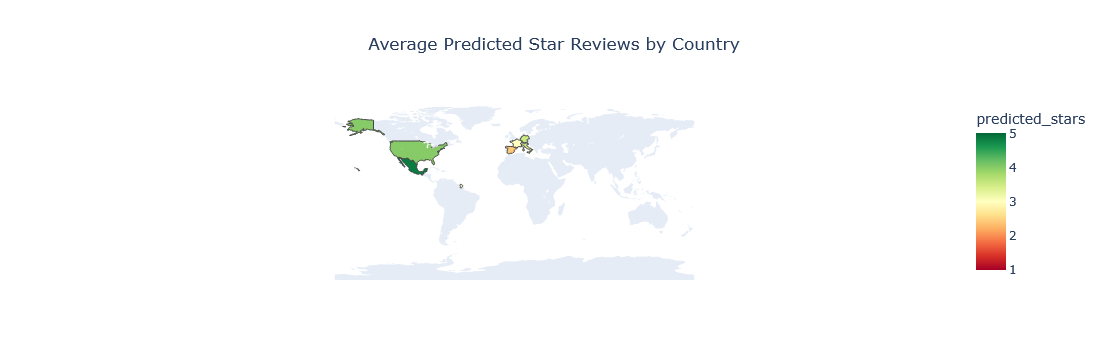

In [46]:
import pandas as pd
import plotly.express as px

# Reload the CSV fresh
df_scoring = pd.read_csv("majority_vote_scores.csv")

# # Check columns and first rows
# print(df_scoring.columns.tolist())
# print(df_scoring.head())

# Group by country
avg_scores = df_scoring.groupby("country", as_index=False)["predicted_stars"].mean()

# Plot the choropleth
fig = px.choropleth(
    avg_scores,
    locations="country",
    locationmode="country names",
    color="predicted_stars",
    color_continuous_scale="RdYlGn",
    range_color=(1, 5),
    title="Average Predicted Star Reviews by Country"
)

fig.update_layout(geo=dict(showframe=False, showcoastlines=False), title_x=0.5)
fig.show()
